In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [120]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [7]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [8]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [45]:
# 1. Create a mask to locate exactly where Age is missing
missing_mask = X_train['Age_imputed'].isnull()

# 2. Find all the UNIQUE fare values for just those missing rows
unique_fares = X_train.loc[missing_mask, 'Fare'].unique()

# 3. Pull one random age for each unique fare 
# (using replace=True ensures we don't run out of ages if there are many unique fares)
sampled_ages = X_train['Age'].dropna().sample(len(unique_fares), replace=True).values

# 4. Create a dictionary linking each unique fare to its designated age
# Example output: {8.05: 22, 15.50: 35, 7.25: 19}
fare_age_mapping = dict(zip(unique_fares, sampled_ages))

# 5. Map those exact ages back into the missing slots based on their fare
X_train.loc[missing_mask, 'Age_imputed'] = X_train.loc[missing_mask, 'Fare'].map(fare_age_mapping)

X_train['Fare'].sum()


np.float64(22989.8079)

In [17]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]

Series([], Name: Age_imputed, dtype: float64)

In [18]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([25.  , 37.  , 56.  , 20.  , 27.  , 54.  , 22.  , 48.  , 31.  ,
       40.  , 46.  , 29.  , 40.  , 17.  , 36.  , 16.  , 52.  , 61.  ,
       45.  ,  6.  , 26.  , 25.  , 34.  , 30.  , 35.  , 26.  , 16.  ,
       49.  , 36.  , 27.  , 62.  , 41.  , 13.  , 20.  , 24.  , 25.  ,
       32.  , 59.  , 54.  , 40.  , 21.  , 18.  , 38.  ,  8.  , 25.  ,
       24.  , 32.  , 47.  , 36.  , 31.  , 29.  , 40.  , 26.  , 40.  ,
       29.  , 39.  , 30.  ,  2.  , 32.  , 20.  , 45.  , 21.  , 31.  ,
       39.  , 39.  , 25.  , 43.  , 22.  ,  4.  , 26.  , 13.  , 24.  ,
       16.  , 20.  , 20.  , 50.  , 48.  , 40.  , 59.  , 16.  , 58.  ,
       25.  , 19.  , 14.  , 22.  ,  2.  ,  4.  , 50.  ,  7.  , 26.  ,
       24.  , 21.  , 37.  , 14.  , 51.  , 45.  , 24.  , 29.  , 62.  ,
       28.  , 41.  ,  3.  , 27.  , 23.  ,  8.  , 16.  , 34.  , 48.  ,
       56.  ,  7.  , 28.  , 30.  , 36.  , 17.  , 23.  ,  4.  , 35.  ,
       22.  , 19.  , 27.  , 28.  , 45.5 , 27.  , 21.  , 38.  , 28.  ,
       51.  , 12.  ,

In [22]:
X_train['Age_imputed'].isnull().sum()

np.int64(0)

In [23]:
X_train.isnull().sum()

Age            148
Fare             0
Age_imputed      0
dtype: int64

/var/folders/69/q9zwcs613054zrngsvhg1p_m0000gn/T/ipykernel_2914/2642582470.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
/var/folders/69/q9zwcs613054zrngsvhg1p_m0000gn/T/ipykernel_2914/2642582470.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5

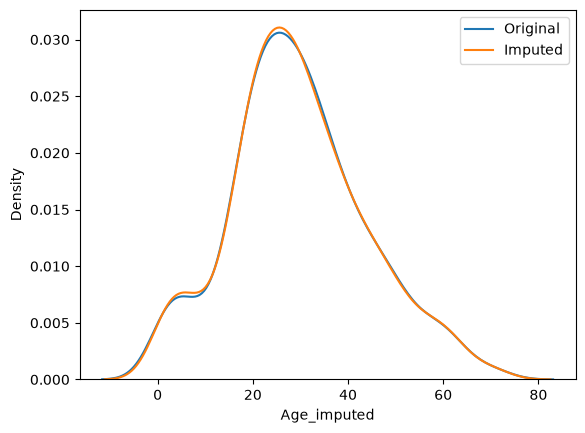

In [33]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [36]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  204.7436797507862


In [37]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,46.130467
Age,71.512440,204.349513,204.349513
Age_imputed,46.130467,204.349513,204.743680


<Axes: >

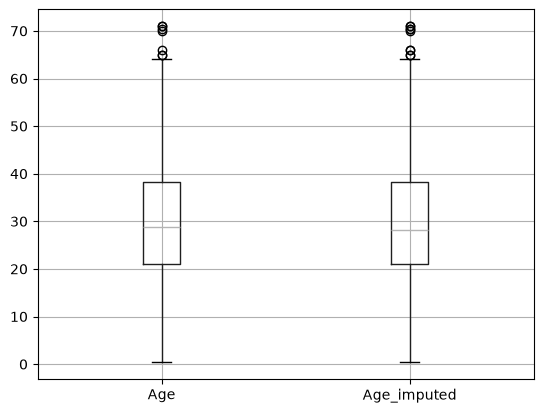

In [38]:
X_train[['Age', 'Age_imputed']].boxplot()

In [29]:
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

NameError: name 'observation' is not defined

In [30]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

FileNotFoundError: [Errno 2] No such file or directory: 'house-train.csv'

In [142]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [143]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [144]:
X = data
y = data['SalePrice']

In [145]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [146]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

<ipython-input-146-7b50da2dfa67>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['GarageQual_imputed'] = X_train['GarageQual']
<ipython-input-146-7b50da2dfa67>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['GarageQual_imputed'] = X_test['GarageQual']
<ipython-input-146-7b50da2dfa67>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

In [147]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
989,NaN,TA,197000,TA,NaN
517,TA,TA,265000,TA,TA
910,NaN,TA,154300,TA,NaN
208,Gd,TA,277000,TA,Gd
340,NaN,TA,202900,TA,NaN


In [148]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

<ipython-input-148-f5eeca8d3074>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
C:\Users\91842\anaconda3\lib\site-packages\pandas\core\generic.py:8765: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._update_inplace(new_data)
<ipython-input-148-f5eeca8d3074>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retu

In [149]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [150]:
temp

,original,imputed
TA,0.951043,0.949486
Fa,0.037171,0.037671
Gd,0.009973,0.011130
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [151]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.648709
TA,0.412439,0.538721
Fa,0.040917,0.052750
Po,0.027823,0.038159
Ex,0.024550,0.032548


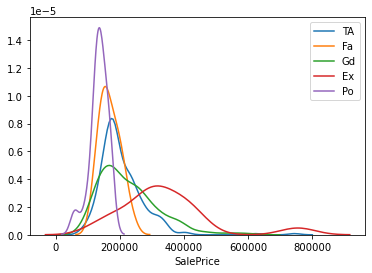

In [152]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

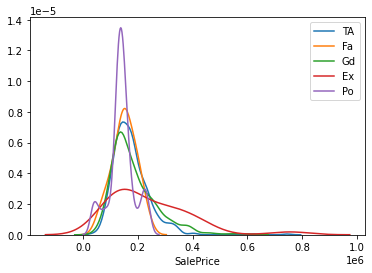

In [153]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()